In [51]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
np.random.seed(0); plt.rcParams["figure.figsize"] = (8, 3.6)
df = pd.read_parquet("../inputs/cartera.parquet")

# A. Exploración de las variables de interes

Describan su ramo y exploren **solo** las variables que importan: la distribución de número de sinsitrsos, exposición y monto de siniestro. Reporten los descriptivos básicos (media, mediana, forma de la cola). No hagan un tour por todo el dataset: enfóquense.

In [52]:
print("Pólizas:", len(df), "| Columnas:", len(df.columns))
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")

Pólizas: 30000 | Columnas: 13
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)


Tasa de frecuencia siniestral: 2.2%
Exposición total              : 24,003 años-póliza
Severidad (monto_promedio)    → media 1,024,668.77 mediana 143,554 


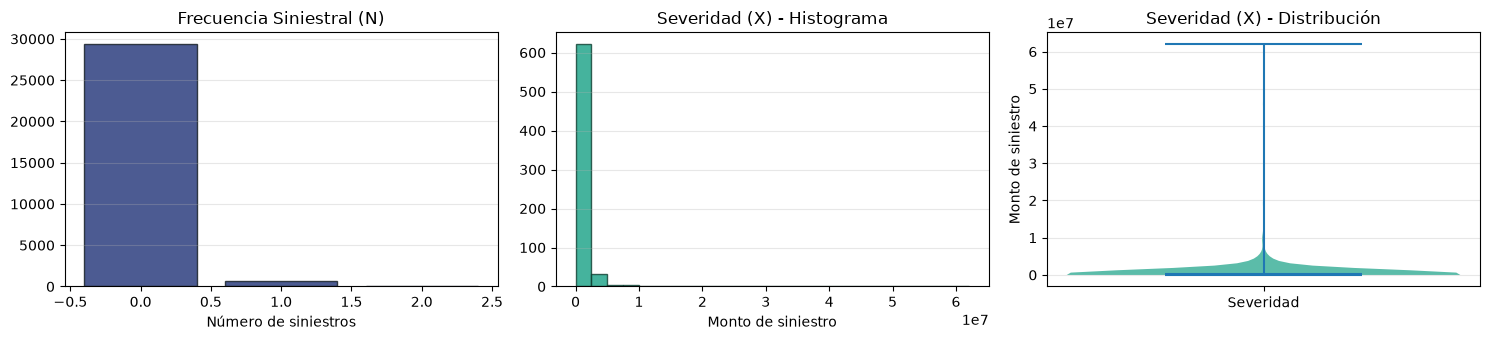

In [53]:
# Exploración enfocada en componentes de la prima pura
 
# Filtrar pólizas con siniestros para estimar E[X] (severidad)
con = df[df.num_siniestros > 0]
 
# Tasa de frecuencia siniestral: proporción de pólizas con ≥1 siniestro
print(f"Tasa de frecuencia siniestral: {(df.num_siniestros>0).mean():.1%}")
 
# Exposición total en años-póliza: normaliza las métricas en el tiempo
print(f"Exposición total              : {df.exposicion.sum():,.0f} años-póliza")
 
# Severidad (E[X]): monto promedio por siniestro en pólizas siniestradas
print(f"Severidad (monto_promedio)    → media {con.monto_promedio_siniestro.mean():,.2f} "
      f"mediana {con.monto_promedio_siniestro.median():,.0f} ")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
 
# Frecuencia N: variable discreta
# Muestra la distribución de conteos de siniestros para revisar si hay Poisson o sobredispersión
ax[0].bar(*np.unique(df.num_siniestros, return_counts=True), color="#2C3E7F", edgecolor="#1A232A", alpha=0.85)
ax[0].set_title("Frecuencia Siniestral (N)"); ax[0].set_xlabel("Número de siniestros")
ax[0].grid(axis='y', alpha=0.3)
 
# Severidad X - Histograma: muestra densidad de frecuencia en rangos de montos
# Útil para ver dónde se concentran los valores y detectar multimodalidad
ax[1].hist(con.monto_promedio_siniestro, bins=int(np.sqrt(len(con))), color="#16A085", edgecolor="#0D3D2F", alpha=0.8)
ax[1].set_title("Severidad (X) - Histograma"); ax[1].set_xlabel("Monto de siniestro")
ax[1].grid(axis='y', alpha=0.3)
 
# Severidad X - Violin plot: muestra cuartiles, mediana y forma de la distribución
# Mejor para comparar asimetría y cola pesada; ve directamente la estructura del riesgo
parts = ax[2].violinplot([con.monto_promedio_siniestro], orientation='vertical', showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor("#16A085")
    pc.set_alpha(0.7)
ax[2].set_title("Severidad (X) - Distribución"); ax[2].set_ylabel("Monto de siniestro")
ax[2].set_xticks([1]); ax[2].set_xticklabels(['Severidad'])
ax[2].grid(axis='y', alpha=0.3)
 
plt.tight_layout(); plt.show()

# B. Severidad

- Ajusten varias distribuciones (lognormal, gamma, Weibull, Pareto…) y **elijan una con criterio**: AIC **y** el comportamiento de la **cola** (no solo el número).
- Consideren las **transformaciones** de la póliza: distingan la severidad **ground-up** (el daño real) de la que **paga la aseguradora** tras aplicar deducible etc. Recuerden lo de la Sesión 3: ajustar sobre datos ya transformados sesga.


In [54]:

#ANÁLISIS POR EL AIC

# Nombramos para poder llamar al monto promedio de los siniestros registrados
x = con.monto_promedio_siniestro.values

# Definimos el Akaike Information Criterior
#Intente equilibrar que tan bien se ajustan los datos al modelo
def aic(dist, pr, d): return 2*len(pr) - 2*np.sum(dist.logpdf(d, *pr))

#Distribuciones a considerar para el ajuste de los datos
candidatas = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
        "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in candidatas.items():
    #.fit nos funciona para estimar los parámetros e ls distr. de acuerdo nuetsros datos
    # floc=0 porque no existen montos negativos
    pr = dist.fit(x, floc=0); ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, x), 1)})
tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
#Se finaliza con la distribució con menor AIC, pues a menor valor, mejor es el modelo
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ La mejor opción por AIC: {mejor}")

Distribución     AIC
   Lognormal 18866.7
     Weibull 19011.9
       Gamma 19221.0
      Pareto 19818.5

→ La mejor opción por AIC: Lognormal


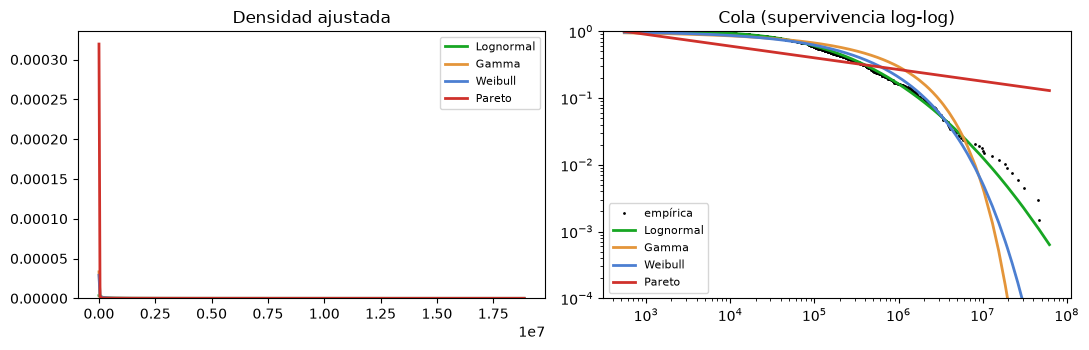

E[X] ground-up (modelo Lognormal) = 893,346
Donde el comportamiento de la empirica tiene un comportamiento similar a la Log-normal, es decir, con una cola pesada


In [55]:
# ANÁLISIS POR LA COLA

#Para poder visualizar la concordancia de las gráficas con nuestrso datos, asignamos colores para diferenciar
col = {"Lognormal":"#17A623","Gamma":"#E4953A","Weibull": "#4C7FD1" ,"Pareto":"#CF312B"}

#Muestra el percentil en el que se encuentra el monto de siniestro que deja aproximadamente al 99% de los datos por debajo de él
p99 = np.percentile(x, 99); grid = np.linspace(x.min(), p99, 400)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(x, bins=70, density=True, range=(x.min(), p99), color="#d9d9d9", edgecolor="white")

for nom,(d,pr) in ajustes.items(): ax[0].plot(grid, d.pdf(grid,*pr), color=col[nom], lw=2, label=nom)
ax[0].set_title("Densidad ajustada"); ax[0].legend(fontsize=8)

xs = np.sort(x); S_emp = 1 - np.arange(1,len(xs)+1)/len(xs)
ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="empírica")

for nom,(d,pr) in ajustes.items(): ax[1].plot(xs, d.sf(xs,*pr), color=col[nom], lw=2, label=nom)
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4,1)

#Título de gráfica de la cola de supervivencia
ax[1].set_title("Cola (supervivencia log-log)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
dist_sev, pr_sev = ajustes[mejor]

print(f"E[X] ground-up (modelo {mejor}) = {dist_sev.mean(*pr_sev):,.0f}")
print("Donde el comportamiento de la empirica tiene un comportamiento similar a la Log-normal, es decir, con una cola pesada")

In [56]:
# Severidad transformada que paga la aseguradora

def transformacion(x, deducible, coaseguro, SA):
    return np.minimum(np.maximum(x - deducible, 0) * (1 - coaseguro), SA)

pagado = transformacion(con.monto_promedio_siniestro.values,
                     con.deducible.values, con.coaseguro.values, con.suma_asegurada.values)
print(f"E[X] ground-up   : {con.monto_promedio_siniestro.mean():,.0f}")
print(f"E[X] transformada: {pagado.mean():,.0f}")
print(f"La póliza absorbe ~{1 - pagado.mean()/con.monto_promedio_siniestro.mean():.1%} de la severidad "
      f"(sobre todo por el deducible).")

E[X] ground-up   : 1,024,669
E[X] transformada: 295,812
La póliza absorbe ~71.1% de la severidad (sobre todo por el deducible).
